<a href="https://colab.research.google.com/github/thaygorh/Analise-de-Dados-e-Boas-Praticas/blob/main/mvp-analise-dados-e-boas-praticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Autor:** Thaygor Henrique Gonçalves

**Matrícula:** 4052025000871

**Dataset:** [Predictive Maintenance Dataset (AI4I 2020)](https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020)


---

## 1. Definição do Problema

Este trabalho utiliza um dataset de manutenção de máquinas, contendo variáveis operacionais como temperatura, velocidade de rotação, torque e desgaste da ferramenta.

O objetivo da análise é identificar quais fatores estão relacionados à ocorrência de falhas e aos diferentes tipos de falha, representados pela variável "machine failure" e pelos indicadores específicos de cada tipo de falha.

A abordagem será baseada em análise exploratória de dados (EDA) e técnicas de pré-processamento, com o objetivo de compreender o comportamento das variáveis, identificar padrões relevantes e avaliar a qualidade dos dados.

Como premissas iniciais, considera-se que:
- Variáveis operacionais podem influenciar diretamente a ocorrência de falhas;
- Diferentes tipos de falha podem estar associados a padrões distintos nos dados;
- A análise exploratória permitirá identificar relações importantes entre variáveis e eventos de falha.

Com isso, espera-se não apenas extrair insights sobre as condições associadas às falhas, mas também preparar a base de dados para possíveis aplicações futuras em modelos de machine learning.

### 1.1 Tipo de Problema

Este é um problema de classificação supervisionada. A variável alvo principal é "machine failure", que indica a ocorrência (1) ou não (0) de falha na máquina.

Além disso, o dataset contém variáveis adicionais que representam tipos específicos de falha (TWF, HDF, PWF, OSF e RNF), permitindo uma análise mais detalhada das condições associadas a cada tipo de ocorrência.

A partir de variáveis operacionais como temperatura, velocidade de rotação, torque e desgaste da ferramenta, busca-se identificar padrões relacionados à ocorrência de falhas e compreender como esses fatores se relacionam com os diferentes tipos de falha.

---

## 2. Dataset e Atributos

### 2.1 Descrição do Dataset

O dataset utilizado neste trabalho é um conjunto de dados sintético voltado para manutenção preditiva em máquinas industriais, modelado com base em um processo real de usinagem (fresagem).

A base contém 10.000 registros, onde cada linha representa uma instância do processo produtivo e cada coluna representa uma variável associada às condições operacionais da máquina e aos eventos de falha.

O objetivo principal do dataset é permitir a análise de padrões que levam à ocorrência de falhas, sendo amplamente utilizado em estudos de manutenção preditiva e machine learning.

O dataset utilizado é público e foi obtido a partir da plataforma Kaggle – Predictive Maintenance Dataset (AI4I 2020)  
Link: https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020



### 2.2 Origem dos Dados

O dataset é sintético, ou seja, foi gerado artificialmente com base em regras e distribuições estatísticas que simulam o comportamento de um sistema real de manufatura.

As variáveis foram construídas a partir de:
- Processos estocásticos (ex: random walk para temperaturas)
- Distribuições normais (ex: torque, velocidade)
- Regras físicas e operacionais (ex: limites de potência, desgaste e sobrecarga)

As falhas são determinadas com base em cinco modos independentes, que representam condições reais de falha em processos industriais.

### 2.3 Variável Alvo

A variável alvo principal do problema é:

- **Machine failure**: indica se ocorreu falha na máquina (0 = não, 1 = sim)

Além disso, o dataset contém variáveis auxiliares que representam tipos específicos de falha:
- TWF – Tool Wear Failure
- HDF – Heat Dissipation Failure
- PWF – Power Failure
- OSF – Overstrain Failure
- RNF – Random Failure

A variável "machine failure" assume valor 1 sempre que pelo menos uma dessas falhas ocorre.


### 2.4 Atributos do Dataset

As variáveis do dataset são descritas a seguir:

- **UDI**: identificador único de cada registro (1 a 10.000)

- **Product ID**: identificador do produto, composto por:
  - Tipo (L, M ou H)
  - Número de série

- **Type**: tipo do produto:
  - L (baixa qualidade – 50%)
  - M (média qualidade – 30%)
  - H (alta qualidade – 20%)

- **Air temperature [K]**: temperatura do ar, gerada por um processo aleatório (random walk)

- **Process temperature [K]**: temperatura do processo, derivada da temperatura do ar com acréscimo e variação controlada

- **Rotational speed [rpm]**: velocidade de rotação, baseada em potência constante com ruído aleatório

- **Torque [Nm]**: torque aplicado, distribuído normalmente em torno de 40 Nm

- **Tool wear [min]**: tempo de desgaste da ferramenta, influenciado pelo tipo do produto

- **Machine failure**: indica falha geral da máquina (variável alvo)

- **TWF (Tool Wear Failure)**: falha por desgaste da ferramenta

- **HDF (Heat Dissipation Failure)**: falha por dissipação de calor insuficiente

- **PWF (Power Failure)**: falha por potência fora dos limites operacionais

- **OSF (Overstrain Failure)**: falha por sobrecarga mecânica

- **RNF (Random Failure)**: falha aleatória independente das condições do processo



### 2.5 Considerações Iniciais sobre os Dados

O dataset apresenta características típicas de problemas industriais, com variáveis numéricas contínuas e indicadores binários de falha.

Por se tratar de um dataset sintético, algumas variáveis seguem distribuições controladas, o que pode influenciar a interpretação dos resultados.

Essas características serão exploradas nas etapas seguintes de análise exploratória de dados.

---

## 3. Hipóteses e Perguntas de Análise

Com base nas características do dataset, foram definidas hipóteses com o objetivo de investigar possíveis relações entre as variáveis operacionais e a ocorrência de falhas nas máquinas.

Cada hipótese é acompanhada de perguntas que irão orientar a análise exploratória dos dados (EDA). As respostas a essas perguntas serão investigadas ao longo da EDA e consolidadas posteriormente na etapa de validação das hipóteses.

### Hipótese 1

**O aumento do desgaste da ferramenta está associado a uma maior probabilidade de ocorrência de falhas.**

Perguntas associadas:
- A máquina com falha apresentam maior desgaste da ferramenta em comparação com máquinas sem falha?
- Existe diferença no desgaste da ferramenta entre os diferentes tipos de falha?
- O desgaste da ferramenta se destaca como uma variável relevante na distinção entre falha e não falha?

### Hipótese 2

**A diferença entre a temperatura do processo e a temperatura do ar está relacionada à ocorrência de falhas.**

Perguntas associadas:
- Existe diferença significativa entre as temperaturas em situações com e sem falha?
- A relação entre temperatura do processo e temperatura do ar indica possíveis condições críticas de operação?
- Algum tipo específico de falha está mais associado a determinadas condições térmicas?

### Hipótese 3

**Valores extremos de torque e velocidade de rotação estão associados à ocorrência de falhas.**

Perguntas associadas:
- A máquina com falha apresentam valores mais elevados ou mais dispersos de torque e velocidade de rotação?
- Existe relação entre torque, velocidade de rotação e tipos específicos de falha?
- Essas variáveis indicam possíveis condições de sobrecarga ou operação anormal?

### Hipótese 4

**O tipo de produto influencia a ocorrência de falhas e a distribuição dos tipos de falha.**

Perguntas associadas:
- Existe diferença na taxa de falha entre produtos do tipo L, M e H?
- O tipo de produto está associado a determinados tipos de falha?
- A qualidade do produto influencia o comportamento de outras variáveis operacionais, como desgaste da ferramenta?


### 3.1 Direcionamento da análise

As hipóteses e perguntas definidas nesta seção orientam toda a análise exploratória dos dados.

Durante a EDA, cada gráfico e análise será utilizado para investigar e levantar evidências relacionadas às perguntas propostas, permitindo identificar padrões e possíveis relações entre as variáveis.

A confirmação ou refutação das hipóteses será realizada posteriormente, com base nos resultados observados ao longo da análise.

---

## 4. Importação e Carga de Dados

Nesta etapa, são importadas as bibliotecas necessárias para análise, visualização e pré-processamento dos dados.

Também é realizada a configuração do ambiente e o carregamento do dataset a partir da URL do repositório no GitHub.

### 4.1 Importação das Bibliotecas

In [521]:
# Configuração para não exibir warnings
import warnings
warnings.filterwarnings('ignore')

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde

# Pré-processamento
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Configuração do estilo dos gráficos
sns.set(style='whitegrid')

### 4.2 Carga dos Dados

In [522]:
# carregamento do dataset
url = "https://raw.githubusercontent.com/thaygorh/Analise-de-Dados-e-Boas-Praticas/refs/heads/main/Predictive%20Maintenance%20Dataset%20AI4I%202020.csv"

df = pd.read_csv(url)

## 5. Estrutura dos Dados

Nesta seção é apresentada a estrutura inicial do dataset, antes da aplicação de qualquer tratamento ou transformação.

O objetivo é compreender a organização dos dados, identificar tipos de variáveis e obter uma visão geral das informações disponíveis.

### 5.1 Visualização inicial dos dados

A seguir, são exibidas as primeiras linhas do dataset, permitindo uma visualização inicial da estrutura e dos valores das variáveis.

In [523]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### 5.2 Dimensões do dataset

Nesta etapa, são verificadas as dimensões do dataset, ou seja, a quantidade de linhas (instâncias) e colunas (atributos).

In [524]:
df.shape

(10000, 14)

### 5.3 Tipos de dados e estrutura

A função `info()` permite observar os tipos de dados de cada variável, além de verificar a presença de valores nulos.

In [525]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

### 5.4 Estatísticas descritivas iniciais

Nesta etapa, são apresentadas estatísticas descritivas básicas das variáveis numéricas, como média, desvio padrão, valores mínimos e máximos.

Essa análise fornece uma visão geral do comportamento dos dados e possíveis variações entre as variáveis.

In [526]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


As estatísticas descritivas indicam que as variáveis apresentam distribuições coerentes, sem indícios de valores extremos inconsistentes nesta análise inicial.

#### 5.4.1 Verificação de valores ausentes

A seguir, é realizada a verificação da presença de valores ausentes no dataset.

In [527]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


Observa-se que não há valores ausentes em nenhuma das variáveis do dataset.

### 5.5 Observações iniciais

O dataset possui 10.000 instâncias e 14 variáveis, com predominância de dados numéricos, além de variáveis categóricas e binárias associadas às falhas.

De forma geral, a estrutura dos dados é consistente e adequada para as análises propostas, sendo as verificações mais detalhadas realizadas nas etapas seguintes.

---

## 6. Limpeza e Padronização Inicial

Nesta etapa, são realizadas transformações iniciais no dataset com o objetivo de melhorar a legibilidade, padronização e organização dos dados.
Essas modificações não alteram o conteúdo das informações, apenas facilitam a análise nas etapas seguintes.

Nesta etapa, são realizadas transformações iniciais no dataset com o objetivo de melhorar a legibilidade, padronização e organização dos dados. Essas modificações não alteram o conteúdo das informações, apenas facilitam a análise nas etapas seguintes.

Esta etapa corresponde a uma preparação inicial dos dados, não contemplando ainda o pré-processamento completo (como normalização, padronização ou tratamento aprofundado), que será realizado posteriormente.

### 6.1 Criação do dataset para análise

Para preservar o dataset original, será criada uma cópia que será utilizada nas etapas de tratamento e análise.

In [528]:
df_analysis = df.copy()

### 6.2 Remoção de colunas irrelevantes

As colunas que não agregam valor analítico foram removidas:

- UDI: identificador único
- Product ID: identificador do produto

In [529]:
df_analysis = df_analysis.drop(columns=['UDI', 'Product ID'])

### 6.3 Padronização dos nomes das colunas

Os nomes das colunas foram ajustados para português, com o objetivo de facilitar a interpretação e manter consistência ao longo da análise.

In [530]:
df_analysis = df_analysis.rename(columns={
    'Type': 'Tipo do produto',
    'Air temperature [K]': 'Temperatura do ar [K]',
    'Process temperature [K]': 'Temperatura do processo [K]',
    'Rotational speed [rpm]': 'Velocidade de rotação [rpm]',
    'Torque [Nm]': 'Torque [Nm]',
    'Tool wear [min]': 'Desgaste da ferramenta [min]',
    'Machine failure': 'Falha da máquina',
    'TWF': 'Falha por desgaste da ferramenta',
    'HDF': 'Falha por dissipação de calor',
    'PWF': 'Falha por potência inadequada',
    'OSF': 'Falha por sobrecarga mecânica',
    'RNF': 'Falha aleatória'
})

### 6.4 Verificação do dataset após ajustes

Após as transformações iniciais, é possível visualizar o dataset atualizado.

In [531]:
df_analysis.head()

,Tipo do produto,Temperatura do ar [K],Temperatura do processo [K],Velocidade de rotação [rpm],Torque [Nm],Desgaste da ferramenta [min],Falha da máquina,Falha por desgaste da ferramenta,Falha por dissipação de calor,Falha por potência inadequada,Falha por sobrecarga mecânica,Falha aleatória
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [532]:
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Tipo do produto                   10000 non-null  object 
 1   Temperatura do ar [K]             10000 non-null  float64
 2   Temperatura do processo [K]       10000 non-null  float64
 3   Velocidade de rotação [rpm]       10000 non-null  int64  
 4   Torque [Nm]                       10000 non-null  float64
 5   Desgaste da ferramenta [min]      10000 non-null  int64  
 6   Falha da máquina                  10000 non-null  int64  
 7   Falha por desgaste da ferramenta  10000 non-null  int64  
 8   Falha por dissipação de calor     10000 non-null  int64  
 9   Falha por potência inadequada     10000 non-null  int64  
 10  Falha por sobrecarga mecânica     10000 non-null  int64  
 11  Falha aleatória                   10000 non-null  int64  
dtypes: fl

### 6.5 Considerações após a preparação

Após as transformações realizadas:

- As colunas irrelevantes foram removidas;
- Os nomes das variáveis foram padronizados e traduzidos para português, facilitando a interpretação;
- O dataset encontra-se organizado e preparado para a etapa de análise exploratória dos dados.
---

## 7. Análise Exploratória dos Dados (EDA)

Nesta etapa, é realizada a análise exploratória dos dados com o objetivo de identificar padrões, comportamentos e possíveis relações entre as variáveis do dataset.

A análise será conduzida por meio de estatísticas descritivas e visualizações, permitindo compreender a distribuição dos dados, diferenças entre situações com e sem falha e possíveis associações entre as variáveis operacionais e a ocorrência de falhas.

As análises desenvolvidas nesta seção são guiadas pelas hipóteses e perguntas definidas anteriormente, servindo como base para a identificação de evidências que serão consolidadas na etapa de validação das hipóteses.

### 7.1 Estatísticas Descritivas

Antes da análise gráfica, são avaliadas as estatísticas descritivas das variáveis numéricas, como média, mediana, desvio padrão e quartis.

Essa etapa permite compreender a tendência central e a dispersão dos dados, servindo como base para interpretação das distribuições apresentadas na sequência.

#### 7.1.1 Média das variáveis

A média foi calculada para as variáveis numéricas do dataset.

Para as variáveis contínuas, a média representa o valor típico observado nos dados.  
Já para as variáveis binárias (indicadores de falha), a média representa a proporção de ocorrência de cada tipo de falha no dataset.

In [533]:
# médias das variáveis contínuas
colunas_continuas = [
    'Temperatura do ar [K]',
    'Temperatura do processo [K]',
    'Velocidade de rotação [rpm]',
    'Torque [Nm]',
    'Desgaste da ferramenta [min]'
]

df_analysis[colunas_continuas].mean()

,0
Temperatura do ar [K],300.00493
Temperatura do processo [K],310.00556
Velocidade de rotação [rpm],1538.77610
Torque [Nm],39.98691
Desgaste da ferramenta [min],107.95100


In [534]:
# médias das variáveis binárias (taxa de falha)
colunas_binarias = [
    'Falha da máquina',
    'Falha por desgaste da ferramenta',
    'Falha por dissipação de calor',
    'Falha por potência inadequada',
    'Falha por sobrecarga mecânica',
    'Falha aleatória'
]

df_analysis[colunas_binarias].mean()

,0
Falha da máquina,0.0339
Falha por desgaste da ferramenta,0.0046
Falha por dissipação de calor,0.0115
Falha por potência inadequada,0.0095
Falha por sobrecarga mecânica,0.0098
Falha aleatória,0.0019


### Interpretação das variáveis binárias na média

As variáveis binárias (0 e 1), que indicam ocorrência de falhas, possuem uma interpretação específica na análise estatística.

Onde:
- 0 representa ausência de falha
- 1 representa ocorrência de falha

Dessa forma, a média dessas variáveis não deve ser interpretada como um valor médio convencional, mas sim como a proporção de ocorrências em relação ao total de registros.

Ou seja, a média pode ser interpretada como:
- Taxa de ocorrência da falha
- Probabilidade empírica da falha no dataset

No caso deste dataset, isso significa que ocorre:

- Falha da máquina = 3,39%
- Falha por desgaste da ferramenta = 0,46%
- Falha por dissipação de calor = 1,15%
- Falha por potência inadequada = 0,95%
- Falha por sobrecarga mecânica = 0,98%
- Falha aleatória = 0,19%

Essa interpretação é importante para compreender a frequência dos eventos e auxilia na análise do comportamento das falhas no conjunto de dados.

#### 7.1.2 Mediana das variáveis

A mediana representa o valor central dos dados, sendo menos sensível a valores extremos (outliers).

Nesta etapa, a mediana será analisada apenas para as variáveis contínuas, pois para variáveis binárias a mediana tende a não trazer informações relevantes.

In [535]:
# mediana das variáveis contínuas
colunas_continuas = [
    'Temperatura do ar [K]',
    'Temperatura do processo [K]',
    'Velocidade de rotação [rpm]',
    'Torque [Nm]',
    'Desgaste da ferramenta [min]'
]

df_analysis[colunas_continuas].median()

,0
Temperatura do ar [K],300.1
Temperatura do processo [K],310.1
Velocidade de rotação [rpm],1503.0
Torque [Nm],40.1
Desgaste da ferramenta [min],108.0


#### 7.1.3 Moda das variáveis

A moda representa o valor mais frequente em cada variável do dataset, indicando o valor mais recorrente observado nos dados.

Nesta etapa, a moda será analisada apenas para as variáveis contínuas, pois para variáveis binárias a moda tende a não trazer informações relevantes.

In [536]:
# moda das variáveis contínuas
colunas_continuas = [
    'Temperatura do ar [K]',
    'Temperatura do processo [K]',
    'Velocidade de rotação [rpm]',
    'Torque [Nm]',
    'Desgaste da ferramenta [min]'
]

df_analysis[colunas_continuas].mode().iloc[0]

,0
Temperatura do ar [K],300.7
Temperatura do processo [K],310.6
Velocidade de rotação [rpm],1452.0
Torque [Nm],40.2
Desgaste da ferramenta [min],0.0


#### 7.1.4 Desvio padrão

O desvio padrão mede a dispersão dos dados em relação à média, indicando o quanto os valores variam dentro de cada variável.

Nesta etapa, o desvio padrão será analisado apenas para as variáveis contínuas, pois para variáveis binárias essa medida tende a não agregar informações relevantes no contexto da análise.

In [537]:
# desvio padrão das variáveis contínuas
colunas_continuas = [
    'Temperatura do ar [K]',
    'Temperatura do processo [K]',
    'Velocidade de rotação [rpm]',
    'Torque [Nm]',
    'Desgaste da ferramenta [min]'
]

df_analysis[colunas_continuas].std()

,0
Temperatura do ar [K],2.000259
Temperatura do processo [K],1.483734
Velocidade de rotação [rpm],179.284096
Torque [Nm],9.968934
Desgaste da ferramenta [min],63.654147


### Interpretação do desvio padrão

Observa-se que a variável **Velocidade de rotação** apresenta o maior desvio padrão em termos absolutos, o que está associado à sua escala mais elevada em relação às demais variáveis.

A variável **Desgaste da ferramenta** também apresenta alta dispersão, indicando variação significativa ao longo das observações.

Por outro lado, as variáveis **Temperatura do ar** e **Temperatura do processo** apresentam baixo desvio padrão, indicando maior estabilidade em seus valores.

Já a variável **Torque** apresenta uma dispersão intermediária.

É importante destacar que a comparação direta dos valores de desvio padrão entre variáveis deve ser feita com cautela, uma vez que cada variável possui escalas e unidades diferentes.
A análise do desvio padrão fornece apenas uma visão inicial da dispersão dos dados.

### 7.2 Distribuição das variáveis contínuas em relação à falha (Histograma)

Os histogramas a seguir são utilizados para analisar a distribuição das variáveis contínuas do dataset.

Além disso, é realizada a comparação entre os registros com falha e sem falha, com o objetivo de identificar possíveis diferenças de comportamento associadas à ocorrência de falhas.

Essa análise permite observar quais intervalos das variáveis apresentam maior concentração de falhas, contribuindo para o entendimento das condições operacionais relacionadas ao problema.

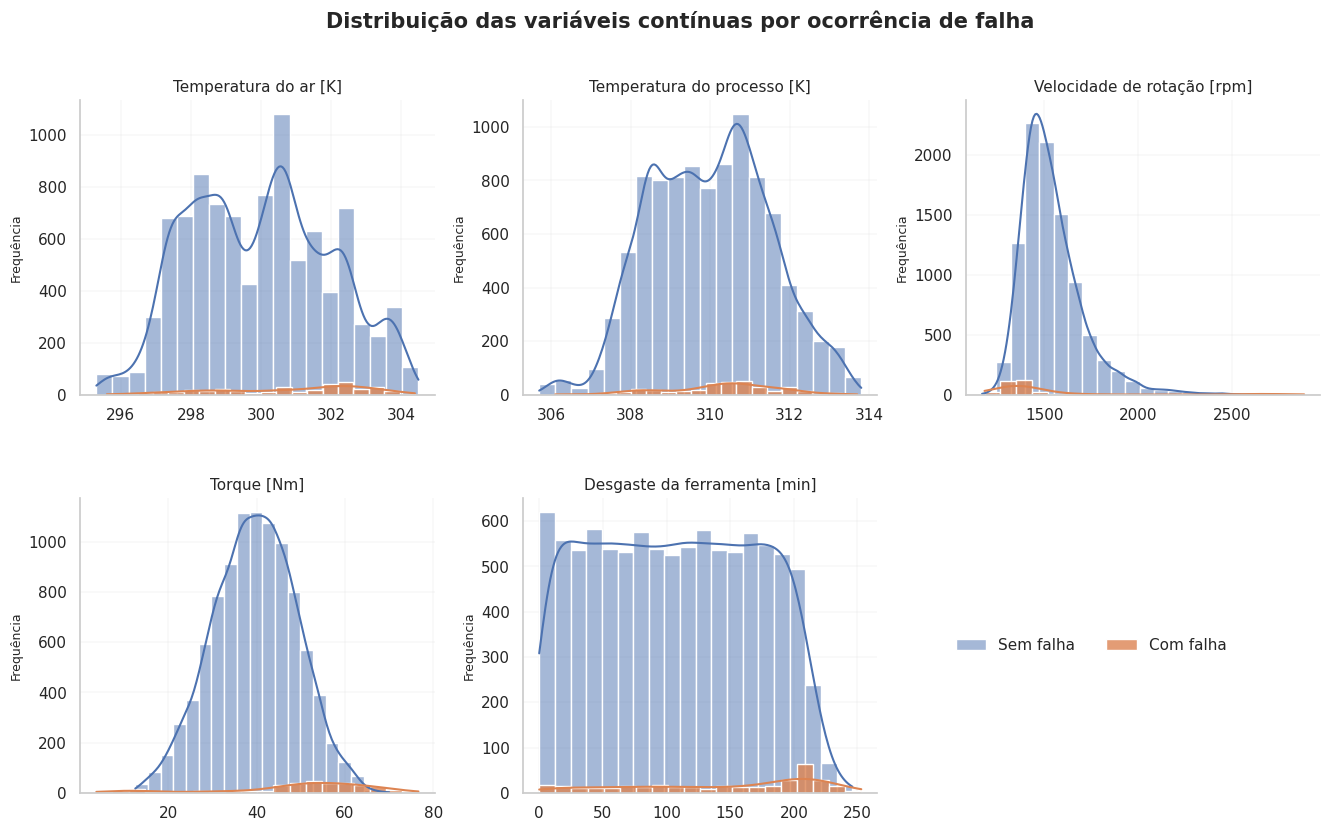

In [538]:
# variáveis contínuas
variaveis = [
    'Temperatura do ar [K]',
    'Temperatura do processo [K]',
    'Velocidade de rotação [rpm]',
    'Torque [Nm]',
    'Desgaste da ferramenta [min]'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, var in enumerate(variaveis):
    ax = axes[i]

    # sem falha
    sns.histplot(
        df_analysis[df_analysis['Falha da máquina'] == 0][var],
        bins=20,
        stat='count',
        kde=True,
        color="#4C72B0",
        alpha=0.5,
        ax=ax,
        label='Sem falha'
    )

    # com falha
    sns.histplot(
        df_analysis[df_analysis['Falha da máquina'] == 1][var],
        bins=20,
        stat='count',
        kde=True,
        color="#DD8452",
        alpha=0.8,
        ax=ax,
        label='Com falha'
    )

    ax.set_title(var, fontsize=11)
    ax.set_ylabel('Frequência', fontsize=9)
    ax.set_xlabel('')

    ax.grid(True, linewidth=0.3, alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# remover gráfico vazio
fig.delaxes(axes[5])

# legenda única para toda a figura
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower right',
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.85, 0.25)
)

fig.suptitle(
    'Distribuição das variáveis contínuas por ocorrência de falha',
    fontsize=15,
    weight='bold',
    y=0.98
)

plt.subplots_adjust(top=0.88, hspace=0.35, wspace=0.25)

plt.show()

### Principais padrões observados nos histogramas

Os histogramas mostram como os registros com falha se distribuem em relação às variáveis contínuas, permitindo comparar seu comportamento com a condição sem falha.

- **Temperatura do ar** e **Temperatura do processo** a distribuição das falhas acompanha a distribuição geral, sem um padrão visual claro que diferencie os grupos.

- **Velocidade de rotação** apresenta maior concentração de falhas em velocidades mais baixas.

- **Torque** apresenta maior concentração de falhas em valores mais elevados, sugerindo relação com aumento de esforço mecânico.

- **Desgaste da ferramenta** apresenta maior concentração de falhas em valores mais altos, indicando associação com o desgaste acumulado.

De forma geral, as variáveis relacionadas ao esforço mecânico e ao desgaste apresentam maior diferença entre os grupos. Já as variáveis de temperatura mostram diferenças mais sutis, sugerindo influência mais localizada na ocorrência de falhas.

### 7.3 Análise comparativa das variáveis por ocorrência de falha (Boxplots)

Os boxplots são utilizados para comparar a distribuição das variáveis contínuas entre os registros com e sem falha.

Essa visualização permite identificar diferenças no comportamento das variáveis, destacando variações na mediana, dispersão e presença de valores extremos.

<Figure size 1500x1000 with 0 Axes>

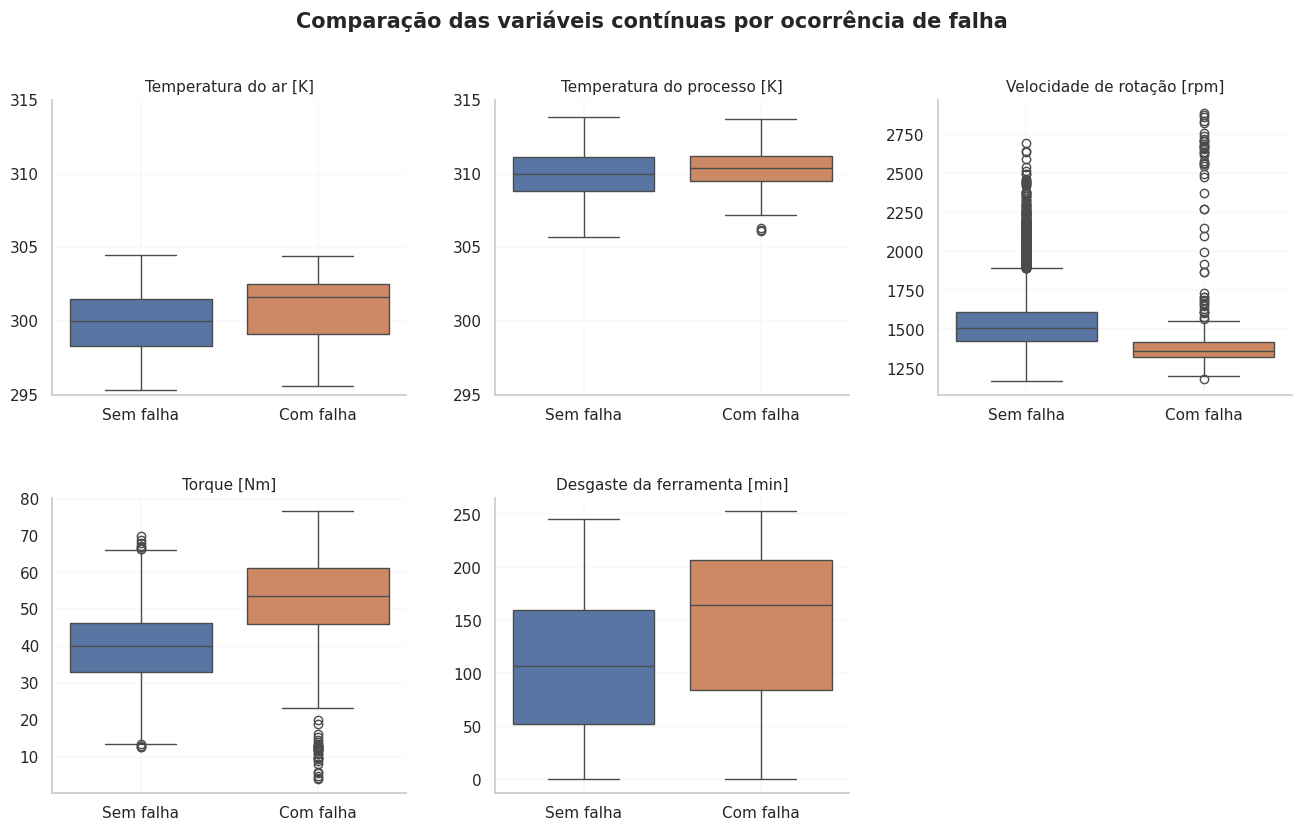

In [539]:
plt.figure(figsize=(15, 10))

variaveis = [
    'Temperatura do ar [K]',
    'Temperatura do processo [K]',
    'Velocidade de rotação [rpm]',
    'Torque [Nm]',
    'Desgaste da ferramenta [min]'
]


fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, var in enumerate(variaveis):
    ax = axes[i]

    sns.boxplot(
        data=df_analysis,
        x='Falha da máquina',
        y=var,
        ax=ax,
        palette=["#4C72B0", "#DD8452"],
        showfliers=True
    )

    ax.set_title(var, fontsize=11)
    ax.set_ylabel('')
    ax.set_xlabel('')

    ax.set_xticklabels(['Sem falha', 'Com falha'])

    # escala fixa para temperaturas
    if var in ['Temperatura do ar [K]', 'Temperatura do processo [K]']:
        ax.set_ylim(295, 315)
        ax.set_yticks(range(295, 316, 5))

    # grid leve
    ax.grid(True, linewidth=0.3, alpha=0.4)

    # remover bordas
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# remover último subplot vazio
fig.delaxes(axes[5])

fig.suptitle(
    'Comparação das variáveis contínuas por ocorrência de falha',
    fontsize=15,
    weight='bold',
    y=0.98
)

plt.subplots_adjust(hspace=0.35, wspace=0.25)

plt.show()

### Principais padrões observados nos boxplots

Os boxplots permitem comparar diretamente o comportamento das variáveis entre os registros com e sem falha, destacando diferenças na mediana, dispersão e presença de valores extremos.

- **Temperatura do ar** apresenta distribuições levemente superiores nos registros com falha. Associada a pequenas variações com o aumento da temperatura.

- **Temperatura do processo** apresenta distribuições semelhantes entre os grupos, sem diferenças relevantes na mediana ou na dispersão.

- **Velocidade de rotação** apresenta mediana inferior nos registros com falha, além de maior dispersão, indicando associação com faixas mais baixas de rotação.

- **Torque** apresenta valores mais elevados no grupo com falha, com maior variabilidade, sugerindo relação com aumento de esforço mecânico.

- **Desgaste da ferramenta** apresenta mediana mais alta e maior dispersão nos registros com falha, indicando associação com o desgaste acumulado.

De forma geral, observa-se que as variáveis relacionadas ao esforço mecânico e ao desgaste apresentam diferenças mais evidentes entre os grupos com e sem falha da máquina. No entanto, essa análise é agregada e não distingue os diferentes tipos de falha, que podem apresentar comportamentos distintos quando analisados individualmente, como será explorado nas etapas seguintes.

### 7.4 Relação linear entre as variáveis (Matriz de Correlação)

A matriz de correlação é utilizada para analisar o grau de relação linear entre as variáveis numéricas do dataset.

Os valores de correlação variam de -1 a 1, onde valores próximos de 1 indicam forte correlação positiva, valores próximos de -1 indicam correlação negativa e valores próximos de 0 indicam ausência de relação linear.

Essa análise permite identificar possíveis associações entre as variáveis, contribuindo para o entendimento das relações existentes no conjunto de dados.

---

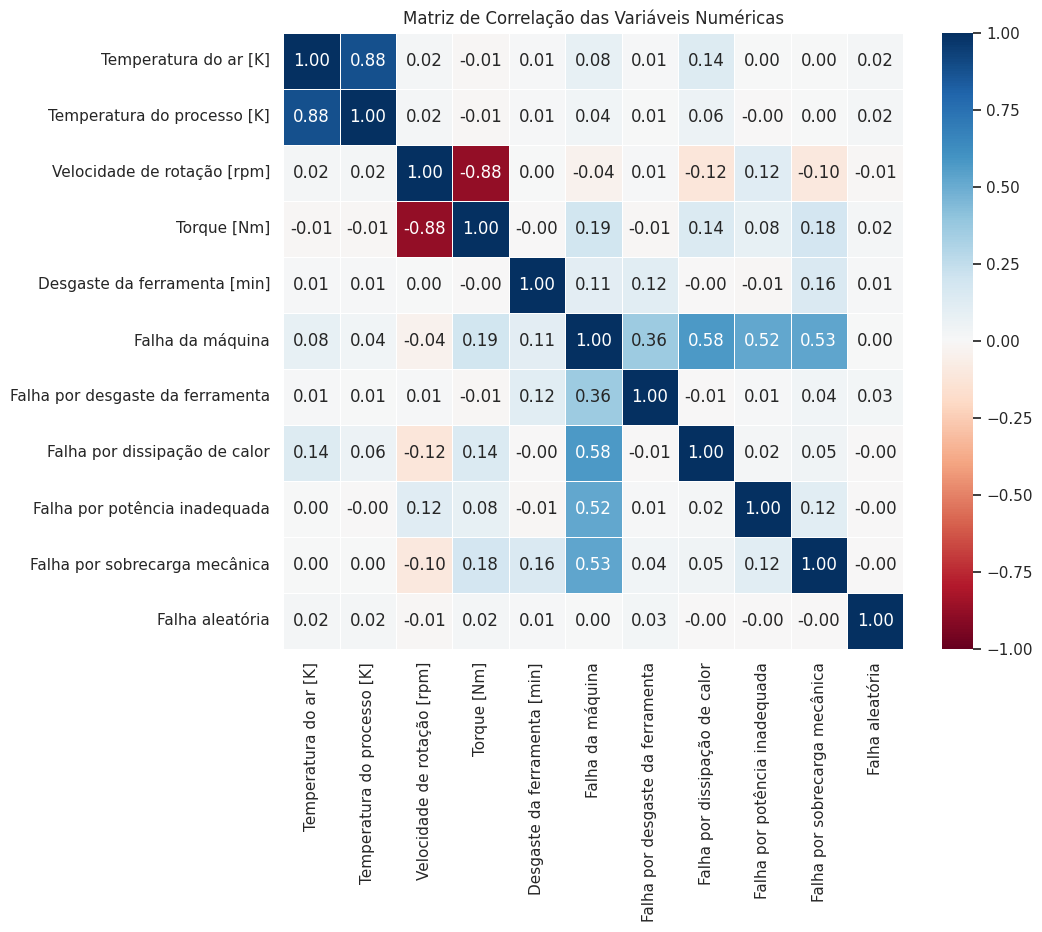

In [540]:
# selecionar apenas colunas numéricas
corr = df_analysis.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='RdBu',
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5
)

plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.show()

### Principais padrões observados na matriz de correlação

A matriz de correlação permite observar a intensidade da relação linear entre as variáveis numéricas do dataset.

Observa-se que:

- **Temperatura do ar** e **Temperatura do processo** apresentam alta correlação positiva, indicando comportamento semelhante entre essas variáveis.

- **Velocidade de rotação** e **Torque** apresentam correlação negativa, indicando alta relação inversa entre essas variáveis.

- As variáveis contínuas apresentam baixa correlação linear com a variável **Falha da máquina**, o que indica que a relação com a falha pode não ser linear ou pode depender da combinação de múltiplas variáveis.

- As variáveis relacionadas aos diferentes tipos de falha apresentam correlação com a variável **Falha da máquina**, o que é esperado, uma vez que essa variável representa a ocorrência de falha geral.

De forma geral, a matriz de correlação fornece uma visão inicial das relações entre as variáveis, mas não é suficiente, isoladamente, para explicar a ocorrência de falhas.



### 7.5 Relação entre variáveis contínuas e tipos de falha (Pairplot)

O pairplot é utilizado para visualizar, de forma conjunta, a distribuição das variáveis contínuas e a relação entre seus pares.

Ao destacar os diferentes tipos de falha por cor, esse gráfico permite observar possíveis padrões de concentração, sobreposição entre classes e combinações de variáveis em que determinadas falhas se tornam mais evidentes.

Essa visualização complementa as análises anteriores, especialmente na identificação de padrões multivariados que não são facilmente observados em gráficos univariados.

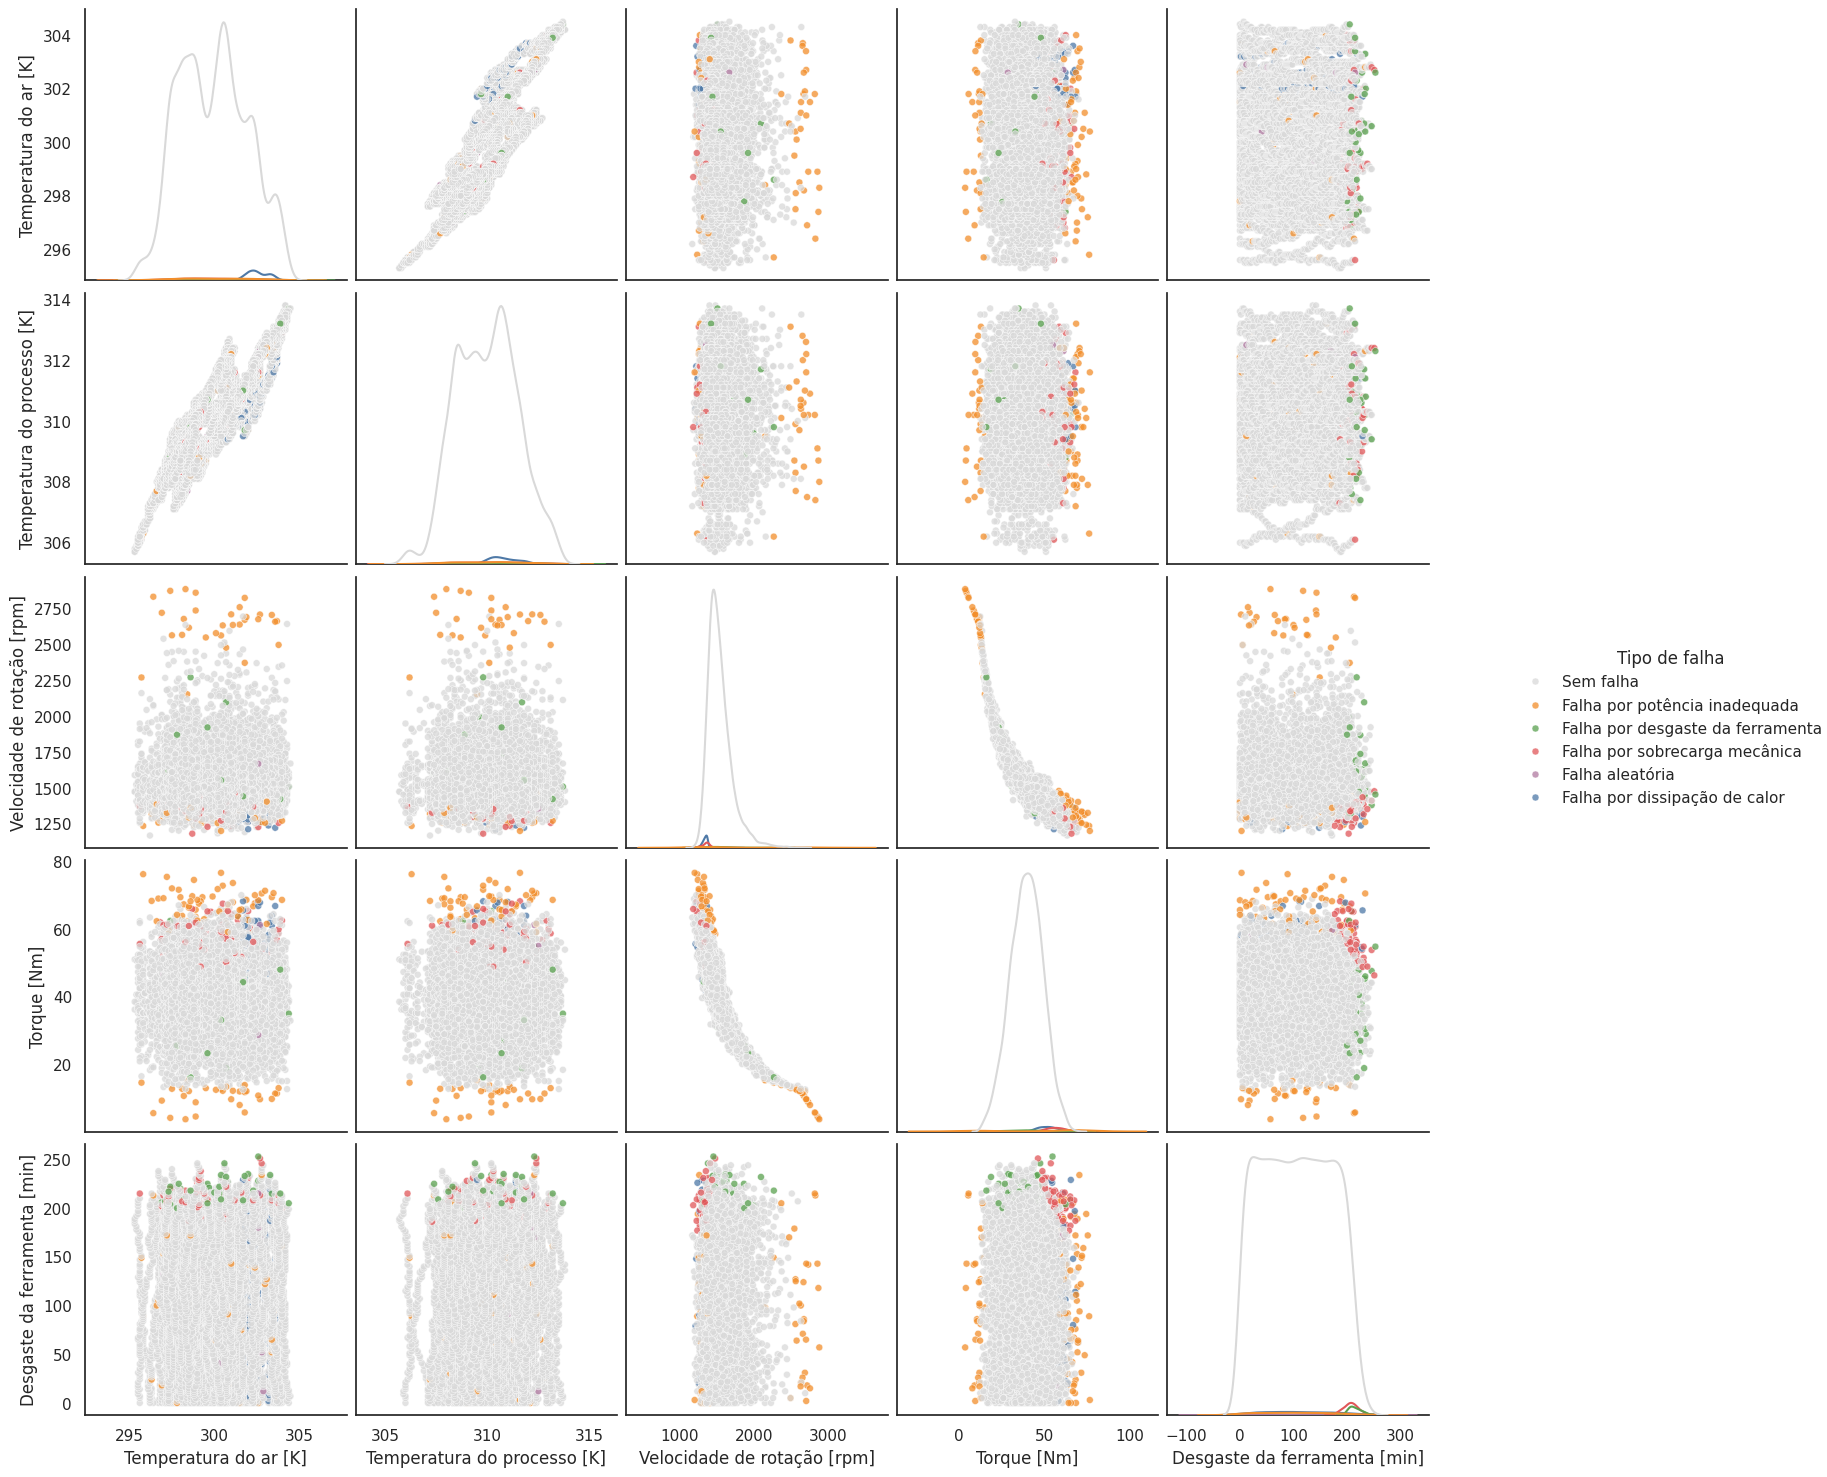

In [541]:
sns.set(style="white", context="notebook")

palette = {
    'Sem falha': '#D9D9D9',
    'Falha por potência inadequada': '#F28E2B',
    'Falha por desgaste da ferramenta': '#59A14F',
    'Falha por sobrecarga mecânica': '#E15759',
    'Falha aleatória': '#B07AA1',
    'Falha por dissipação de calor': '#4E79A7'
}

# coluna categórica com o tipo de falha
def map_failure(row):
    if row['Falha por desgaste da ferramenta'] == 1:
        return 'Falha por desgaste da ferramenta'
    elif row['Falha por dissipação de calor'] == 1:
        return 'Falha por dissipação de calor'
    elif row['Falha por potência inadequada'] == 1:
        return 'Falha por potência inadequada'
    elif row['Falha por sobrecarga mecânica'] == 1:
        return 'Falha por sobrecarga mecânica'
    elif row['Falha aleatória'] == 1:
        return 'Falha aleatória'
    else:
        return 'Sem falha'

df_analysis['Tipo de falha'] = df_analysis.apply(map_failure, axis=1)

# pairplot para comparar variáveis por tipo de falha
g = sns.pairplot(
    df_analysis[
        [
            'Temperatura do ar [K]',
            'Temperatura do processo [K]',
            'Velocidade de rotação [rpm]',
            'Torque [Nm]',
            'Desgaste da ferramenta [min]',
            'Tipo de falha'
        ]
    ],
    hue='Tipo de falha',
    palette=palette,
    diag_kind='kde',          # distribuição na diagonal
    height=3.2,
    plot_kws={
        's': 25,
        'alpha': 0.75         # reduz sobreposição
    },
    diag_kws={
        'fill': False
    }
)

# ajuste de layout
g.fig.set_size_inches(18, 15)
g._legend.set_bbox_to_anchor((1.02, 0.5))
g._legend.set_title('Tipo de falha')
g.fig.subplots_adjust(right=0.80)

plt.show()

### Principais padrões observados no pairplot

O pairplot permite observar, de forma conjunta, a distribuição das variáveis contínuas e sua relação com os diferentes tipos de falha.

A classe **Sem falha** é predominante no conjunto de dados, o que já era esperado. Entre os registros com falha, observa-se que algumas classes apresentam regiões de maior concentração associadas a determinadas condições operacionais.

Em termos de distribuição, as falhas não se apresentam de forma totalmente aleatória, sendo possível identificar alguns padrões:

- **Falha por potência inadequada** tende a se concentrar em cenários de **alta velocidade de rotação** combinada com **baixo torque**, sugerindo associação com condições operacionais específicas.

- **Falha por desgaste da ferramenta** e **Falha por sobrecarga mecânica** apresentam maior incidência em valores elevados de **desgaste da ferramenta**, indicando possível relação com o desgaste acumulado.

- **Falha por dissipação de calor** não apresenta separação visual clara em relação às variáveis de temperatura, sugerindo que essas variáveis, isoladamente, não são suficientes para diferenciar esse tipo de falha.

Além disso, a relação entre **Velocidade de rotação** e **Torque** evidencia um comportamento inverso consistente, independentemente do tipo de falha, refletindo uma característica estrutural do sistema.

De forma geral, observa-se alta sobreposição entre os diferentes tipos de falha, indicando que a distinção entre as classes não é simples e depende da combinação de múltiplas variáveis.

É importante destacar que o pairplot representa a distribuição espacial dos dados, mas não a frequência de ocorrência das falhas. Dessa forma, padrões visuais mais evidentes não necessariamente correspondem aos tipos de falha mais recorrentes no dataset.



### 7.6 Distribuição dos tipos de falha

Nesta etapa, é analisada a frequência de ocorrência de cada tipo de falha no conjunto de dados.

O objetivo é identificar quais falhas são mais recorrentes, complementando a análise visual realizada anteriormente no pairplot.

Para isso, são considerados apenas os registros em que ocorreu falha, permitindo uma comparação direta entre os diferentes modos de falha.

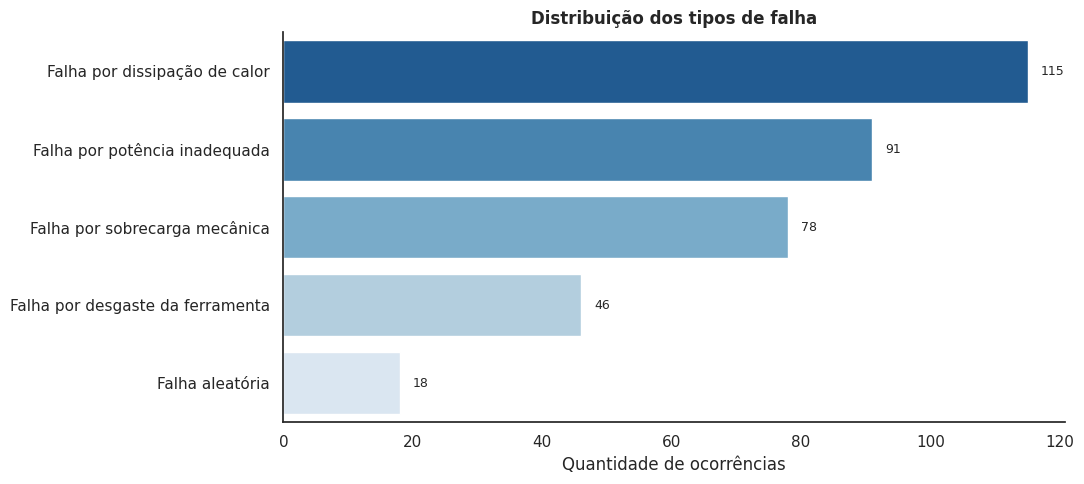

In [542]:
# filtrar apenas os registros com falha
df_failures = df_analysis[df_analysis['Tipo de falha'] != 'Sem falha'].copy()

# contagem dos tipos de falha
counts = df_failures['Tipo de falha'].value_counts()

# ordenar do mais frequente para o menos frequente
counts = counts.sort_values(ascending=False)

plt.figure(figsize=(11, 5))

# gráfico de barras horizontal
ax = sns.barplot(
    x=counts.values,
    y=counts.index,
    palette='Blues_r'
)

# adicionar valores ao final de cada barra
for i, v in enumerate(counts.values):
    ax.text(v + 2, i, str(v), va='center', fontsize=9)

# ajustes de apresentação
plt.title('Distribuição dos tipos de falha', fontsize=12, weight='bold')
plt.xlabel('Quantidade de ocorrências')
plt.ylabel('')

sns.despine()
plt.grid(False)

plt.tight_layout()
plt.show()

### Interpretação da distribuição das falhas

A comparação entre o pairplot e o gráfico de distribuição dos tipos de falha evidencia limitações importantes na interpretação visual dos dados.

Embora o pairplot permita observar a distribuição das falhas no espaço das variáveis, ele não representa adequadamente a frequência de ocorrência de cada tipo de falha.

No gráfico de barras, observa-se que a **falha por dissipação de calor** é a mais recorrente no dataset. No entanto, no pairplot, esse tipo de falha não se destaca visualmente com a mesma intensidade.

Isso ocorre porque esse tipo de falha tende a se concentrar em regiões específicas do espaço de variáveis. Como o pairplot representa dispersão e não frequência absoluta, falhas concentradas podem parecer menos representativas visualmente.

Esse comportamento evidencia que diferentes tipos de visualização devem ser utilizados de forma complementar, sendo importante analisar tanto a distribuição espacial quanto a frequência dos eventos para uma interpretação mais completa.


### 7.7 Comparação das variáveis contínuas por tipo de falha (Boxplots)

Os boxplots são utilizados para analisar a distribuição das variáveis contínuas em função dos diferentes tipos de falha.

Diferentemente da análise anterior, que considerava apenas a ocorrência geral de falha da máquina, nesta etapa os dados são segmentados por tipo de falha, permitindo uma análise mais detalhada do comportamento de cada classe.

A condição **Sem falha** é utilizada como referência do comportamento operacional normal, possibilitando identificar desvios associados a cada tipo de falha.

Essa abordagem complementa a análise de frequência realizada anteriormente, permitindo avaliar não apenas quais falhas são mais recorrentes, mas também como cada tipo de falha se relaciona com as variáveis operacionais.

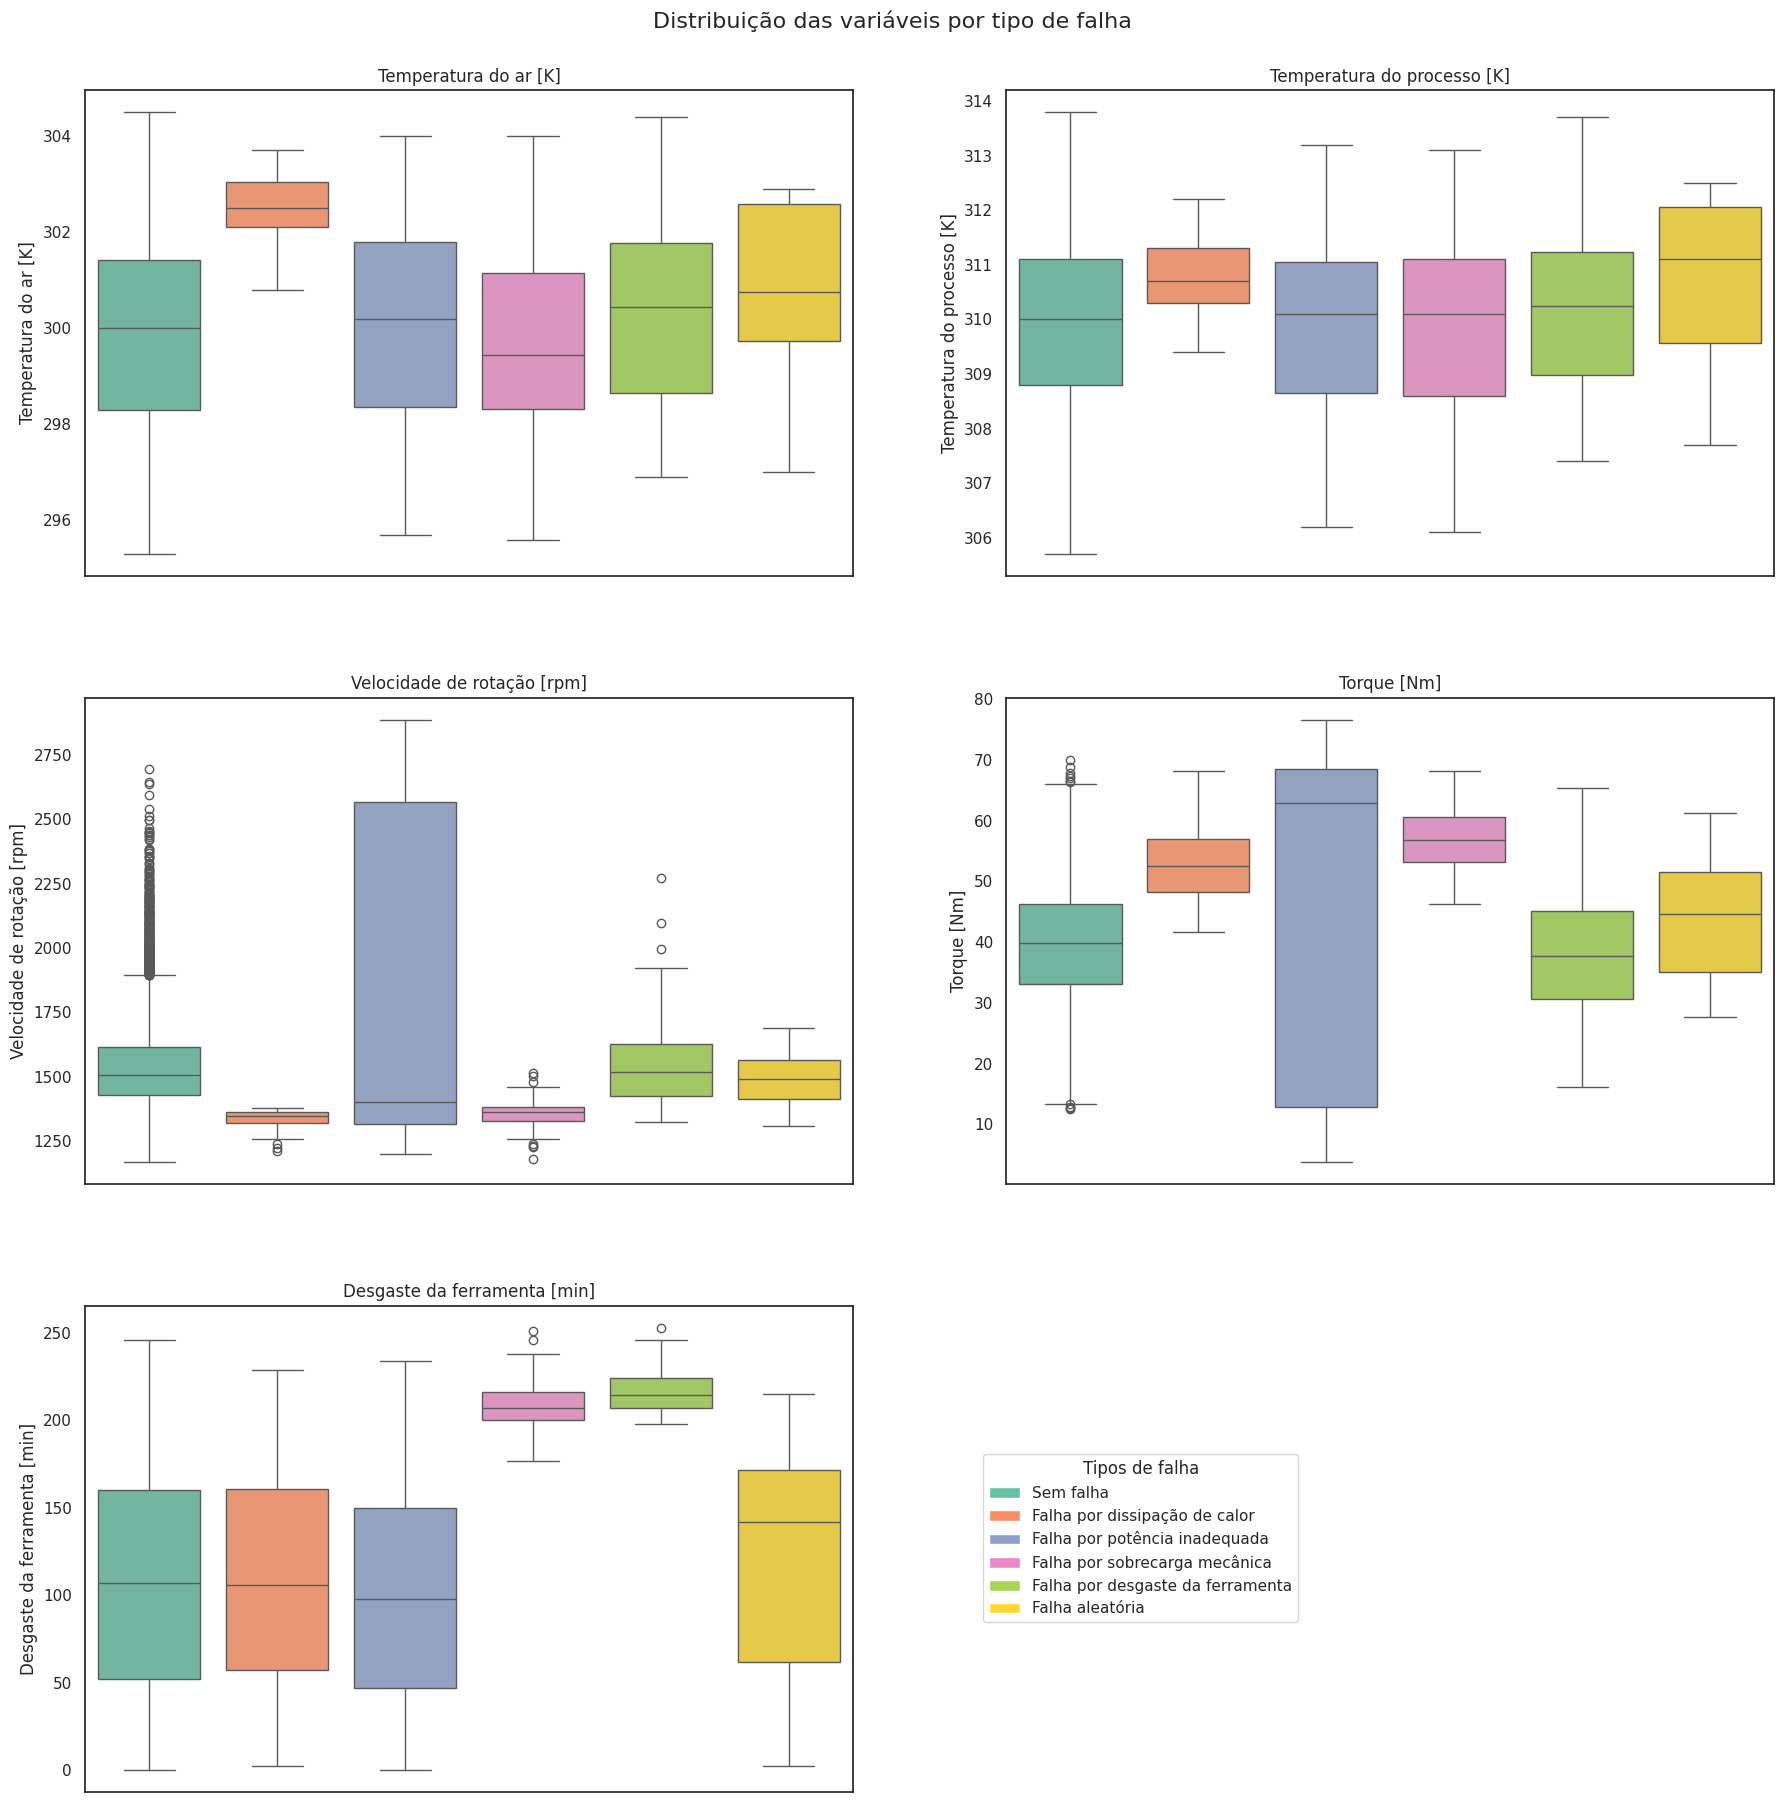

In [543]:
plt.figure(figsize=(18, 18))

variaveis = [
    'Temperatura do ar [K]',
    'Temperatura do processo [K]',
    'Velocidade de rotação [rpm]',
    'Torque [Nm]',
    'Desgaste da ferramenta [min]'
]

ordem_falhas = [
    'Sem falha',
    'Falha por dissipação de calor',
    'Falha por potência inadequada',
    'Falha por sobrecarga mecânica',
    'Falha por desgaste da ferramenta',
    'Falha aleatória'

]

cores = sns.color_palette('Set2', n_colors=len(ordem_falhas))

for i, var in enumerate(variaveis):
    plt.subplot(3, 2, i + 1)

    ax = sns.boxplot(
        data=df_analysis,
        x='Tipo de falha',
        y=var,
        order=ordem_falhas,
        palette=cores
    )

    ax.set_xticklabels([])
    ax.set_xlabel('')
    plt.title(var, fontsize=12)

plt.subplot(3, 2, 6)
plt.axis('off')

plt.suptitle(
    'Distribuição das variáveis por tipo de falha',
    fontsize=16,
    y=1.00
)

legend_elements = [
    Patch(facecolor=cores[i], label=ordem_falhas[i])
    for i in range(len(ordem_falhas))
]

plt.figlegend(
    handles=legend_elements,
    title='Tipos de falha',
    loc='lower right',
    bbox_to_anchor=(0.73, 0.10)
)

plt.tight_layout()
plt.subplots_adjust(hspace=0.25, wspace=0.20)

plt.show()

### Principais padrões observados nos boxplots por tipo de falha

A segmentação por tipo de falha permite identificar diferenças mais específicas no comportamento das variáveis, que não eram visíveis na análise agregada.

Ao comparar o comportamento de cada variável entre os diferentes tipos de falha, observa-se que:

- A condição **Sem falha** apresenta distribuições serve como referência para identificar diferenças nos demais grupos.

- A **Falha por dissipação de calor** apresenta valores ligeiramente mais elevados de `Temperatura do ar`, com `Velocidade de rotação` inferior ao padrão observado e `Torque` mais elevado em relação à condição sem falha.

- A **Falha por potência inadequada** apresenta alta variabilidade na `Velocidade de rotação`, com distribuição bastante dispersa e mediana inferior à condição sem falha. O `Torque` também apresenta maior dispersão, com mediana superior, indicando comportamento distinto nessa combinação de variáveis.

- A **Falha por sobrecarga mecânica** apresenta valores mais baixos de `Velocidade de rotação`, com níveis mais elevados de `Torque` e `Desgaste da ferramenta`, destacando-se em relação aos demais grupos nessas variáveis.

- A **Falha por desgaste da ferramenta** apresenta valores elevados de `Desgaste da ferramenta`, enquanto as demais variáveis permanecem próximas às observadas na condição sem falha.

- A **Falha aleatória** se mantém próxima da condição **Sem falha**, sem um padrão claro de correlação.

De forma geral, observa-se que a distinção entre os tipos de falha não ocorre de forma isolada em uma única variável, sendo necessário considerar a combinação entre múltiplas variáveis para uma melhor caracterização dos padrões observados.

### 7.8 Distribuição das falhas por tipo do produto

A variável **Tipo do produto** classifica os registros em três categorias, associadas ao nível de qualidade do produto:

- **L (Low)**: baixa qualidade;
- **M (Medium)**: qualidade intermediária;
- **H (High)**: alta qualidade.

Essa classificação permite analisar como diferentes condições de operação se refletem na ocorrência de falhas.

Nesta etapa, são avaliadas:

- a distribuição da falha geral por tipo do produto;
- e a relação entre o tipo do produto e os diferentes modos de falha.

O objetivo é identificar possíveis padrões associados a cada categoria.

#### 7.8.1 Ocorrência de falha por tipo do produto

O gráfico a seguir apresenta a quantidade de registros com e sem falha em cada categoria de **Tipo do produto**.

Essa visualização permite observar a distribuição absoluta das falhas entre os grupos, considerando o volume total de registros em cada categoria.

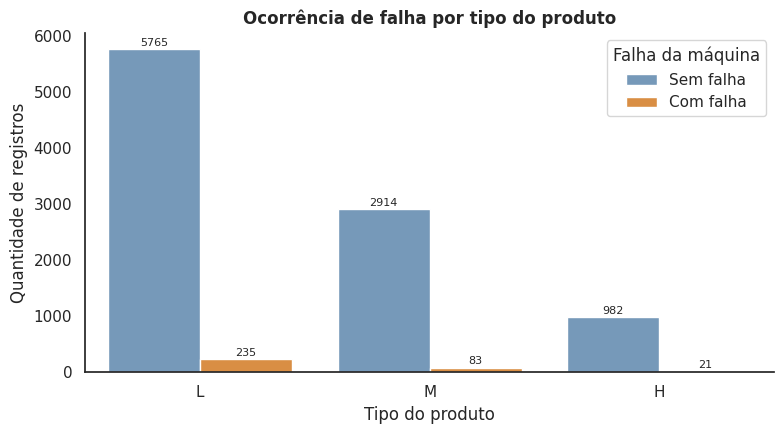

In [544]:
ordem_tipo = ['L', 'M', 'H']

plt.figure(figsize=(8, 4.5))

ax = sns.countplot(
    data=df_analysis,
    x='Tipo do produto',
    hue='Falha da máquina',
    order=ordem_tipo,
    palette=['#6B9AC4', '#F28E2B']
)

ax.set_title('Ocorrência de falha por tipo do produto', fontsize=12, weight='bold')
ax.set_xlabel('Tipo do produto')
ax.set_ylabel('Quantidade de registros')

ax.legend(title='Falha da máquina', labels=['Sem falha', 'Com falha'])

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width() / 2, height + 20),
            ha='center',
            va='bottom',
            fontsize=8
        )

sns.despine()
plt.grid(False)
plt.tight_layout()
plt.show()

Observa-se que o tipo **L** concentra a maior quantidade de registro com falha, seguido pelos tipos **M** e **H**. No entanto, essa análise deve ser interpretada com cautela, pois a quantidade total de registros também varia entre as categorias.

Por esse motivo, além da contagem absoluta, torna-se importante analisar a taxa de falha por tipo do produto, apresentada no gráfico seguinte.

#### 7.8.2 Taxa de falha por tipo do produto

O gráfico a seguir complementa a análise anterior ao apresentar a proporção de falhas em cada categoria de **Tipo do produto**.

Diferentemente da contagem absoluta, essa visualização permite comparar os grupos de forma proporcional, reduzindo o efeito da diferença no número total de registros entre as categorias.

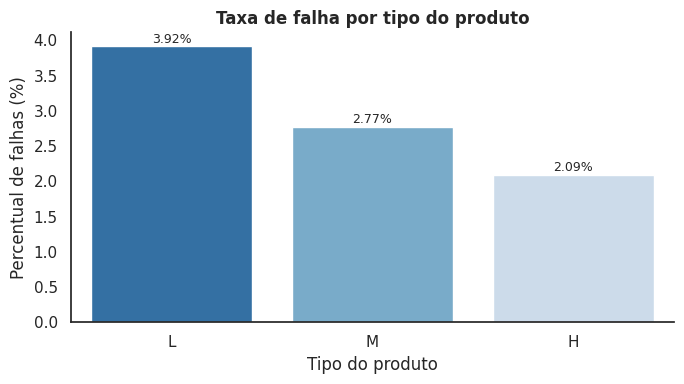

In [545]:
falha_por_tipo = (
    df_analysis.groupby('Tipo do produto')['Falha da máquina']
    .mean()
    .mul(100)
    .reindex(['L', 'M', 'H'])
)

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    x=falha_por_tipo.index,
    y=falha_por_tipo.values,
    palette='Blues_r'
)

for i, v in enumerate(falha_por_tipo.values):
    ax.text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=9)

ax.set_title('Taxa de falha por tipo do produto', fontsize=12, weight='bold')
ax.set_xlabel('Tipo do produto')
ax.set_ylabel('Percentual de falhas (%)')

sns.despine()
plt.grid(False)
plt.tight_layout()
plt.show()

Ao considerar a proporção de falhas, observa-se que o tipo **L** apresenta a maior taxa de falha, seguido por **M** e **H**.

Esse resultado complementa o gráfico anterior e mostra que a maior concentração de falhas no tipo **L** não decorre apenas do maior número de registros, mas também de uma maior participação relativa de falhas.

A análise proporcional mostra que a ocorrência de falhas varia entre os tipos de produto, o que não é evidente na contagem absoluta.

#### 7.8.3 Tipos de falha por tipo do produto

Além da falha geral, também é importante observar como os diferentes modos de falha se distribuem entre as categorias de **Tipo do produto**.

A matriz a seguir permite identificar quais tipos de falha apresentam maior quantidade de ocorrências em cada grupo, ampliando a análise realizada nos gráficos anteriores.

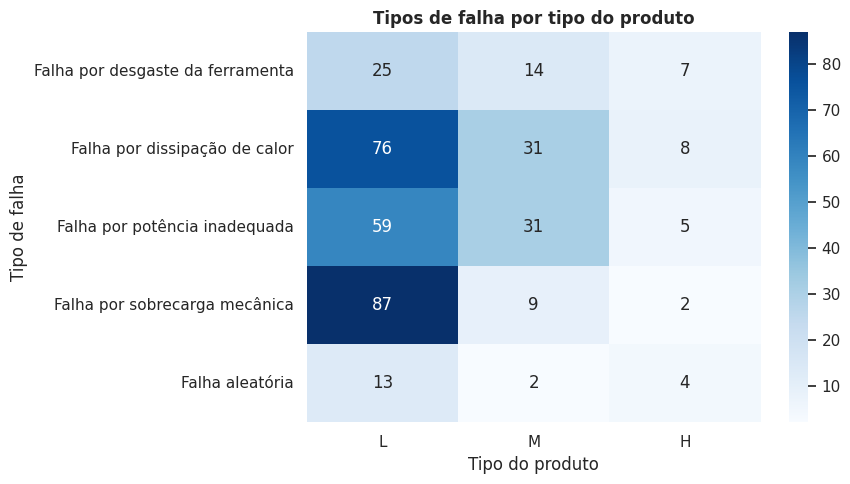

In [546]:
falhas_cols = [
    'Falha por desgaste da ferramenta',
    'Falha por dissipação de calor',
    'Falha por potência inadequada',
    'Falha por sobrecarga mecânica',
    'Falha aleatória'
]

falhas_por_tipo = (
    df_analysis.groupby('Tipo do produto')[falhas_cols]
    .sum()
    .reindex(ordem_tipo)
    .T
)

plt.figure(figsize=(9, 5))

ax = sns.heatmap(
    falhas_por_tipo,
    annot=True,
    fmt='.0f',
    cmap='Blues'
)

ax.set_title('Tipos de falha por tipo do produto', fontsize=12, weight='bold')
ax.set_xlabel('Tipo do produto')
ax.set_ylabel('Tipo de falha')

plt.tight_layout()
plt.show()

A matriz evidencia que as ocorrências de falhas estão concentradas principalmente no tipo L, com redução consistente nos tipos M e H em praticamente todos os modos de falha.

- O tipo **L** concentra a maior quantidade de ocorrências na maioria dos modos de falha, com destaque para **Falha por sobrecarga mecânica**, **Falha por dissipação de calor** e **Falha por potência inadequada**.

- O tipo **M** também apresenta ocorrência relevante de **Falha por dissipação de calor** e **Falha por potência inadequada**, porém em menor volume quando comparado ao tipo L.

- O tipo **H** apresenta menor quantidade de ocorrências em todos os modos de falha, mantendo o padrão observado nas análises anteriores.

De forma geral, a matriz confirma o comportamento observado nas análises anteriores, indicando que o **Tipo do produto** está associado à variação na ocorrência das falhas, tanto na visão geral quanto na distribuição dos diferentes modos de falha.

### 7.9 Encerramento EDA

A análise exploratória permitiu compreender a estrutura dos dados e identificar padrões relacionados à ocorrência das falhas.

Foram observadas diferenças no comportamento das variáveis entre registros com e sem falha, bem como entre os diferentes tipos de falha e categorias de produto.

Além disso, verificou-se que diferentes formas de visualização evidenciam aspectos distintos dos dados, sendo importante utilizar abordagens complementares para uma análise mais consistente.

---

## 8. Pré-processamento de Dados (Preparação Final)

Nesta etapa, são realizadas operações de tratamento e preparação dos dados com o objetivo de torná-los adequados para análises mais aprofundadas e possíveis aplicações em modelos de machine learning.

Diferentemente das etapas anteriores, que tiveram foco exploratório e organizacional, o pré-processamento envolve intervenções diretas nos dados, como verificação de qualidade, tratamento de inconsistências e aplicação de transformações.

As operações realizadas nesta etapa incluem:

- Verificação da qualidade dos dados (valores faltantes, duplicados e inconsistências);
- Tratamento de possíveis valores inválidos;
- Aplicação de técnicas de normalização e padronização;
- Preparação final do dataset para análise ou modelagem.

Cada uma dessas etapas será detalhada a seguir, com a devida justificativa das decisões adotadas.

### 8.1 Qualidade dos Dados

Nesta etapa, são realizadas verificações relacionadas à qualidade dos dados, com o objetivo de identificar possíveis problemas que possam impactar as análises ou etapas posteriores.

Serão avaliados:

- Valores faltantes;
- Registros duplicados;
- Possíveis inconsistências nos dados.

#### Valores faltantes

Conforme verificado anteriormente (Tópico 5.4.1), o dataset não possui valores ausentes em nenhuma das variáveis, não sendo necessário tratamento para dados faltantes nesta etapa.

#### Registros duplicados

A verificação de registros duplicados indica que não há duplicidade de instâncias no dataset.

Dessa forma, não é necessário realizar remoção de registros nesta etapa.

In [547]:
df_analysis.duplicated().sum()

np.int64(0)

#### Inconsistências nos dados

Com base nas análises realizadas até o momento, não foram identificadas inconsistências aparentes nos dados.

As variáveis apresentam valores coerentes com o contexto do problema, não havendo indícios de registros inválidos ou fora do esperado nesta etapa.

Ressalta-se que, por se tratar de um dataset sintético, construído a partir de regras e distribuições controladas, é esperado um comportamento mais consistente dos dados.

De forma geral, o dataset apresenta boa qualidade, estando completo, sem registros duplicados e sem inconsistências aparentes.

### 8.2 Tratamento de Dados

Nesta etapa, são avaliados possíveis valores inválidos ou fora do esperado, com o objetivo de identificar a necessidade de tratamento adicional nos dados.

In [548]:
# Verificação de valores negativos onde não deveria ter valores negativos
(df_analysis[['Temperatura do ar [K]',
              'Temperatura do processo [K]',
              'Torque [Nm]',
              'Desgaste da ferramenta [min]']] < 0).sum()

,0
Temperatura do ar [K],0
Temperatura do processo [K],0
Torque [Nm],0
Desgaste da ferramenta [min],0


In [549]:
# Verificação dos valores únicos nas variáveis binárias (esperado: 0 e 1)
df_analysis[
    [
        'Falha da máquina',
        'Falha por desgaste da ferramenta',
        'Falha por dissipação de calor',
        'Falha por potência inadequada',
        'Falha por sobrecarga mecânica',
        'Falha aleatória'
    ]
].apply(lambda x: sorted(x.unique()))

,Falha da máquina,Falha por desgaste da ferramenta,Falha por dissipação de calor,Falha por potência inadequada,Falha por sobrecarga mecânica,Falha aleatória
0,0,0,0,0,0,0
1,1,1,1,1,1,1


As verificações realizadas indicam que não há valores negativos nas variáveis que representam grandezas físicas, o que está coerente com o contexto do problema.

Além disso, observa-se que as variáveis binárias assumem apenas os valores esperados, variando entre 0 e 1.

Dessa forma, não foram identificados valores inválidos no dataset, não sendo necessário tratamento nesta etapa.

#### 8.3 Normalização

Nesta etapa, as variáveis numéricas contínuas são transformadas para uma mesma escala, permitindo análise comparativa direta entre seus comportamentos.

A padronização de escala elimina o efeito da magnitude original dos dados, possibilitando avaliar diferenças estruturais entre as variáveis.

#### 8.3.1 Seleção das variáveis

Foram consideradas as variáveis numéricas contínuas associadas às condições operacionais do processo, por apresentarem diferentes escalas e relevância direta para a análise.

Variáveis categóricas e binárias foram mantidas fora desta etapa, uma vez que já se encontram em formato adequado para interpretação e não sofrem influência de escala.

In [550]:
# Selecionando variáveis numéricas contínuas
colunas_numericas = [
    'Temperatura do ar [K]',
    'Temperatura do processo [K]',
    'Velocidade de rotação [rpm]',
    'Torque [Nm]',
    'Desgaste da ferramenta [min]'
]

#### 8.3.2 Aplicação da normalização

A transformação é aplicada às variáveis selecionadas, ajustando seus valores para um intervalo comum.

In [551]:
# Aplicação da normalização
scaler = MinMaxScaler()

df_normalizado = df_analysis.copy()
df_normalizado[colunas_numericas] = scaler.fit_transform(df_analysis[colunas_numericas])

#### 8.3.3 Análise da distribuição das variáveis normalizadas

A seguir, é apresentada a distribuição das variáveis após a normalização, com o objetivo de analisar seus comportamentos relativos em uma mesma escala.

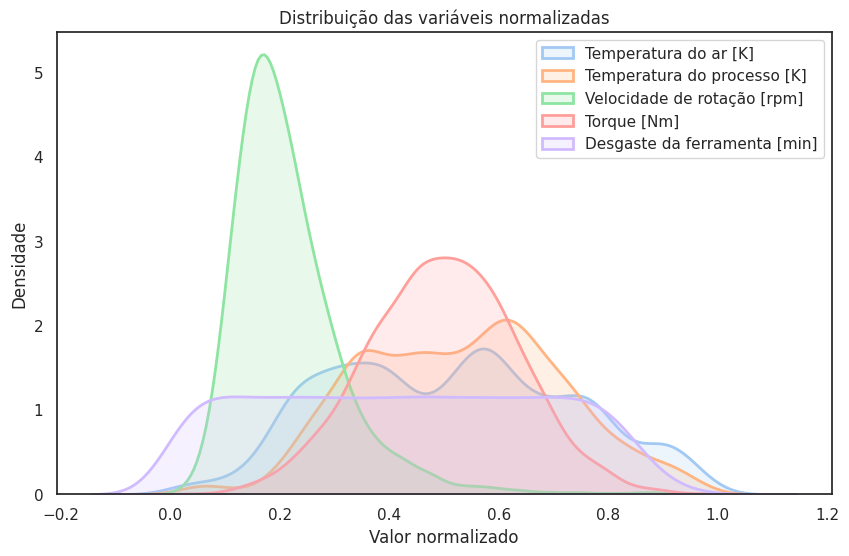

In [552]:
plt.figure(figsize=(10, 6))

cores = sns.color_palette('pastel', n_colors=len(colunas_numericas))

for i, col in enumerate(colunas_numericas):
    sns.kdeplot(
        df_normalizado[col],
        label=col,
        color=cores[i],
        fill=True,       # mantém preenchimento
        alpha=0.2,       # leve para não poluir
        linewidth=2,
        bw_adjust=1.2    # suaviza curva
    )

plt.title('Distribuição das variáveis normalizadas')
plt.xlabel('Valor normalizado')
plt.ylabel('Densidade')

plt.legend()
plt.show()

Observa-se que a **Velocidade de rotação [rpm]** apresenta maior concentração em faixas específicas, indicando menor variabilidade relativa.

Já **Desgaste da ferramenta [min]** apresenta distribuição mais uniforme, sugerindo maior dispersão ao longo da escala.

As variáveis **Temperatura do ar [K]**, **Temperatura do processo [K]** e **Torque [Nm]** apresentam comportamentos intermediários, com uma distribuição centralizada.

A normalização permite a comparação direta entre as variáveis, evidenciando diferenças de dispersão e concentração que seriam pouco perceptíveis na escala original.

#### 8.4 Padronização

Nesta etapa, as variáveis numéricas contínuas são padronizadas com o objetivo de permitir comparação direta entre seus comportamentos, eliminando o efeito de diferenças de escala.

A seguir, são verificadas a média e o desvio padrão das variáveis após a transformação, como forma de validar a aplicação da padronização.

In [553]:
scaler = StandardScaler()

df_padronizado = df_analysis.copy()
df_padronizado[colunas_numericas] = scaler.fit_transform(df_analysis[colunas_numericas])

#### 8.4.1 Validação da padronização
A seguir, são verificadas a média e o desvio padrão das variáveis após a padronização, com o objetivo de confirmar o efeito da transformação aplicada.

In [554]:
df_padronizado[colunas_numericas].agg(['mean', 'std'])

,Temperatura do ar [K],Temperatura do processo [K],Velocidade de rotação [rpm],Torque [Nm],Desgaste da ferramenta [min]
mean,-9.322321e-16,-1.693934e-15,-2.330580e-16,5.424994e-16,1.051603e-16
std,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00


Os resultados confirmam que as variáveis foram adequadamente padronizadas, apresentando média próxima de zero e desvio padrão próximo de um.

#### 8.4.2 Análise da distribuição das variáveis padronizadas

A distribuição das variáveis padronizadas é apresentada a seguir, com o objetivo de avaliar o comportamento relativo entre os atributos após a transformação.

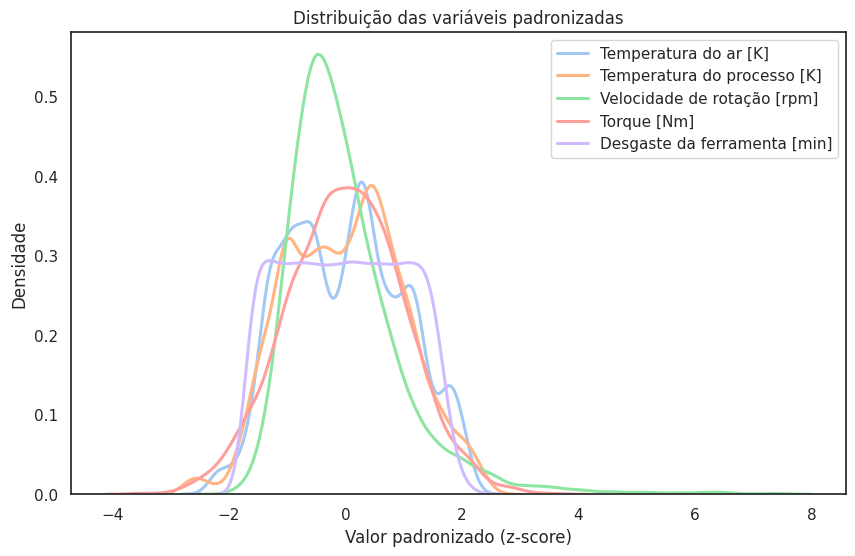

In [555]:
plt.figure(figsize=(10, 6))

cores = sns.color_palette('pastel', n_colors=len(colunas_numericas))

for i, col in enumerate(colunas_numericas):
    sns.kdeplot(
        df_padronizado[col],
        label=col,
        color=cores[i],
        linewidth=2.2
    )

plt.title('Distribuição das variáveis padronizadas')
plt.xlabel('Valor padronizado (z-score)')
plt.ylabel('Densidade')

plt.legend()
plt.show()

Observa-se que, após a padronização, todas as variáveis passam a estar centradas em torno de zero, o que favorece a comparação direta de seus comportamentos relativos.

A variável **Velocidade de rotação [rpm]** apresenta a distribuição mais concentrada, com maior pico de densidade e assimetria positiva, indicando menor dispersão em torno da média e presença de valores mais afastados na cauda direita.

Já **Desgaste da ferramenta [min]** mantém uma distribuição mais espalhada e menos concentrada, evidenciando comportamento mais uniforme ao longo da escala padronizada.

As variáveis **Temperatura do ar [K]**, **Temperatura do processo [K]** e **Torque [Nm]** apresentam distribuições intermediárias, com formatos mais suaves e relativamente próximos entre si.

Esses resultados indicam que, embora a padronização alinhe as variáveis em termos de média e variância, as diferenças estruturais entre suas distribuições foram preservadas.

#### 8.5 Feature Engineering

Nesta etapa, foi aplicada uma técnica de Feature Engineering com o objetivo de enriquecer a análise e capturar relações não explícitas entre as variáveis originais.

A motivação para essa abordagem está relacionada ao fato de que a falha por dissipação de calor se destaca como a ocorrência mais frequente no dataset, indicando que fatores térmicos possuem papel relevante no comportamento do sistema.

#### 8.5.1 Criação da variável diferença de temperatura
Diante disso, foi criada a variável **Diferença de temperatura [K]**, definida como a diferença entre a temperatura do processo e a temperatura do ar.

Essa transformação busca representar o gradiente térmico do sistema, permitindo uma análise mais direta de possíveis condições associadas ao aquecimento e à dissipação de calor.

In [556]:
# Criando nova variável de Feature Engineering (gradiente térmico)
df_analysis['Diferença de temperatura [K]'] = (
    df_analysis['Temperatura do processo [K]'] -
    df_analysis['Temperatura do ar [K]']
)

#### 8.5.2 Análise da diferença de temperatura por ocorrência de falha

Inicialmente, foi utilizada uma visualização única com sobreposição das distribuições. No entanto, essa abordagem dificultou a interpretação dos dados, devido à sobreposição das curvas e à diferença significativa na quantidade de registros entre os grupos com e sem falha.

Diante disso, optou-se pela utilização de gráficos separados, permitindo uma análise mais clara e comparável entre os dois cenários.

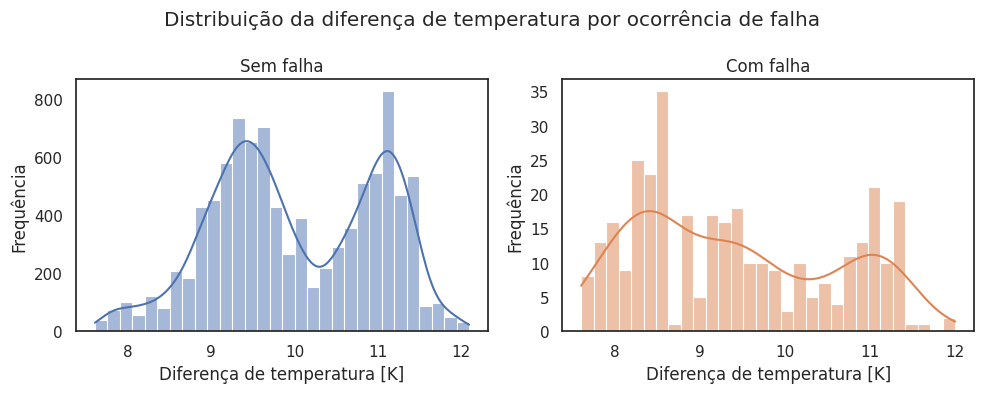

In [557]:
plt.figure(figsize=(10, 4))

# Sem falha
plt.subplot(1, 2, 1)
sns.histplot(
    data=df_analysis[df_analysis['Falha da máquina'] == 0],
    x='Diferença de temperatura [K]',
    bins=30,
    kde=True,
    color='#4C72B0'
)
plt.title('Sem falha')
plt.xlabel('Diferença de temperatura [K]')
plt.ylabel('Frequência')

# Com falha
plt.subplot(1, 2, 2)
sns.histplot(
    data=df_analysis[df_analysis['Falha da máquina'] == 1],
    x='Diferença de temperatura [K]',
    bins=30,
    kde=True,
    color='#DD8452'
)
plt.title('Com falha')
plt.xlabel('Diferença de temperatura [K]')
plt.ylabel('Frequência')

plt.suptitle('Distribuição da diferença de temperatura por ocorrência de falha')

plt.tight_layout()
plt.show()

Observa-se que, nos casos com falha, a distribuição da diferença de temperatura tende a se concentrar em valores menores quando comparada aos casos sem falha. Esse comportamento indica que as falhas ocorrem, predominantemente, em condições onde o gradiente térmico entre o processo e o ambiente é reduzido.

Esse padrão é coerente com o comportamento observado anteriormente na análise exploratória, indicando que, em cenários onde a temperatura do ar se eleva e se aproxima da temperatura do processo, ocorre um aumento no registro de falhas.

Esse comportamento é consistente com a predominância da falha por dissipação de calor no dataset, evidenciando o papel crítico das condições térmicas na ocorrência de falhas.

---

## 9. Validação das Hipóteses

Com base na análise exploratória dos dados e nas transformações realizadas na etapa de pré-processamento, são avaliadas as hipóteses formuladas ao longo do trabalho.

A validação é conduzida a partir da consolidação das evidências observadas nos dados, permitindo verificar se os padrões identificados sustentam as relações propostas entre as variáveis e a ocorrência de falhas.

#### 9.1 Hipótese 1 — Desgaste da ferramenta

**Hipótese:**  
O aumento do desgaste da ferramenta está associado a uma maior probabilidade de ocorrência de falhas.

**Evidências:**  
A análise das distribuições (seção [7.2](https://colab.research.google.com/github/thaygorh/Analise-de-Dados-e-Boas-Praticas/blob/main/mvp-analise-dados-e-boas-praticas.ipynb#scrollTo=oS9NbYMp7e_t) — Distribuição das variáveis contínuas em relação à falha) mostra diferenças no comportamento da variável desgaste entre os cenários com e sem falha.

A análise conjunta das variáveis (seção [7.5](https://colab.research.google.com/github/thaygorh/Analise-de-Dados-e-Boas-Praticas/blob/main/mvp-analise-dados-e-boas-praticas.ipynb#scrollTo=QJskYUqNXnjc) — Relação entre variáveis contínuas e tipos de falha) evidencia que as falhas associadas ao desgaste da ferramenta se concentram em níveis mais elevados dessa variável.

Além disso, a análise comparativa por meio de boxplots (seção [7.7](https://colab.research.google.com/github/thaygorh/Analise-de-Dados-e-Boas-Praticas/blob/main/mvp-analise-dados-e-boas-praticas.ipynb#scrollTo=GJCn0MGewJu6) — Comparação das variáveis contínuas por tipo de falha) evidencia um deslocamento da distribuição para valores superiores nos casos com falha, com maior concentração em níveis mais elevados de desgaste.

Esses padrões indicam uma relação consistente entre o desgaste da ferramenta e a ocorrência de falhas.

**Conclusão:**  
A hipótese é **confirmada**, indicando que níveis mais elevados de desgaste da ferramenta estão associados a uma maior probabilidade de ocorrência de falhas.

Observa-se que o aumento do desgaste está diretamente relacionado a condições mais propensas à ocorrência de falhas, especialmente aquelas associadas ao próprio desgaste da ferramenta, além de apresentar presença relevante em cenários de sobrecarga mecânica.

#### 9.2 Hipótese 2 — Condições térmicas

**Hipótese:**  
A diferença entre a temperatura do processo e a temperatura do ar está relacionada à ocorrência de falhas.

**Evidências:**  
A análise das distribuições (seção [7.2](https://colab.research.google.com/github/thaygorh/Analise-de-Dados-e-Boas-Praticas/blob/main/mvp-analise-dados-e-boas-praticas.ipynb#scrollTo=oS9NbYMp7e_t) — Distribuição das variáveis contínuas em relação à falha) indica ausência de separação visual clara entre os cenários com e sem falha para as variáveis de temperatura.

A análise conjunta (seção [7.5](https://colab.research.google.com/github/thaygorh/Analise-de-Dados-e-Boas-Praticas/blob/main/mvp-analise-dados-e-boas-praticas.ipynb#scrollTo=QJskYUqNXnjc) — Relação entre variáveis contínuas e tipos de falha) evidencia forte correlação entre a temperatura do ar e a temperatura do processo. No entanto, esse tipo de visualização não permite avaliar diretamente a quantidade de falhas.

Isso ocorre porque o pairplot representa a distribuição espacial dos dados, e não a frequência de ocorrência. Além disso, as falhas tendem a se concentrar em um intervalo relativamente restrito de valores, o que dificulta a identificação visual de padrões relacionados à quantidade de ocorrências.

A análise por tipo de falha (seção [7.7](https://colab.research.google.com/github/thaygorh/Analise-de-Dados-e-Boas-Praticas/blob/main/mvp-analise-dados-e-boas-praticas.ipynb#scrollTo=GJCn0MGewJu6) — Comparação das variáveis contínuas por tipo de falha) mostra que, nos casos de falha por dissipação de calor, a temperatura do ar tende a apresentar valores ligeiramente mais elevados em relação à condição sem falha.

Adicionalmente, a distribuição dos tipos de falha (seção [7.6](https://colab.research.google.com/github/thaygorh/Analise-de-Dados-e-Boas-Praticas/blob/main/mvp-analise-dados-e-boas-praticas.ipynb#scrollTo=wcuGRiIfbVML) — Distribuição dos tipos de falha) indica que a falha por dissipação de calor é a mais frequente no dataset.

A partir da variável criada por Feature Engineering (seção [8.5.2](https://colab.research.google.com/github/thaygorh/Analise-de-Dados-e-Boas-Praticas/blob/main/mvp-analise-dados-e-boas-praticas.ipynb#scrollTo=uX3IkQ-L-UwL) — Análise da diferença de temperatura por ocorrência de falha), observa-se que os casos com falha se concentram em menores valores de diferença de temperatura.

**Conclusão:**  
A hipótese é **confirmada**, indicando que a diferença entre a temperatura do processo e a temperatura do ar está associada à ocorrência de falhas.

Observa-se que falhas ocorrem predominantemente em cenários com menor diferença de temperatura, evidenciando que a elevação da temperatura do ar reduz o gradiente térmico e está relacionada ao aumento da ocorrência de falhas.

#### 9.3 Hipótese 3 — Variáveis operacionais

**Hipótese:**  
Valores extremos de torque e velocidade de rotação estão associados à ocorrência de falhas.

**Evidências:**  
A análise das distribuições (seção [7.2](https://colab.research.google.com/github/thaygorh/Analise-de-Dados-e-Boas-Praticas/blob/main/mvp-analise-dados-e-boas-praticas.ipynb#scrollTo=oS9NbYMp7e_t) — Distribuição das variáveis contínuas em relação à falha) indica que as falhas tendem a se concentrar em velocidades de rotação mais baixas e em valores mais elevados de torque.

Esse comportamento é reforçado pela análise comparativa por meio de boxplots (seção [7.3](https://colab.research.google.com/github/thaygorh/Analise-de-Dados-e-Boas-Praticas/blob/main/mvp-analise-dados-e-boas-praticas.ipynb#scrollTo=T_b6RD0sUrau) — Análise comparativa das variáveis por ocorrência de falha), que evidencia mediana inferior de velocidade de rotação nos registros com falha, além de maior dispersão, indicando associação com faixas mais baixas de rotação. Para o torque, observam-se valores mais elevados no grupo com falha, com maior variabilidade, sugerindo relação com aumento de esforço mecânico.

A análise da matriz de correlação (seção [7.4](https://colab.research.google.com/github/thaygorh/Analise-de-Dados-e-Boas-Praticas/blob/main/mvp-analise-dados-e-boas-praticas.ipynb#scrollTo=imJTnTLqWBAd) — Relação linear entre as variáveis) mostra que velocidade de rotação e torque apresentam forte correlação negativa, indicando relação inversa entre essas variáveis.

A análise conjunta das variáveis (seção [7.5](https://colab.research.google.com/github/thaygorh/Analise-de-Dados-e-Boas-Praticas/blob/main/mvp-analise-dados-e-boas-praticas.ipynb#scrollTo=QJskYUqNXnjc) — Relação entre variáveis contínuas e tipos de falha) evidencia que a falha por potência inadequada tende a se concentrar em cenários de alta velocidade de rotação combinada com baixo torque, indicando um padrão operacional específico distinto das demais falhas. Além disso, reforça o comportamento inverso entre velocidade de rotação e torque como característica estrutural do sistema.

Complementarmente, a análise por tipo de falha (seção [7.7](https://colab.research.google.com/github/thaygorh/Analise-de-Dados-e-Boas-Praticas/blob/main/mvp-analise-dados-e-boas-praticas.ipynb#scrollTo=GJCn0MGewJu6) — Comparação das variáveis contínuas por tipo de falha) mostra que:

- A falha por potência inadequada apresenta alta variabilidade na velocidade de rotação e no torque, indicando comportamento instável nessas variáveis.
- A falha por sobrecarga mecânica se destaca por ocorrer em cenários de baixa rotação, alto torque e maior desgaste da ferramenta, evidenciando associação com condições de elevado esforço mecânico.

Esses resultados, em conjunto, indicam que diferentes tipos de falha estão associados a padrões operacionais específicos envolvendo torque e velocidade de rotação.

**Conclusão:**  
A hipótese é **parcialmente confirmada**, indicando que valores extremos de torque e velocidade de rotação estão associados à ocorrência de falhas, especialmente em cenários de maior esforço mecânico.

Observa-se que falhas tendem a ocorrer em condições de baixa rotação e alto torque, enquanto padrões específicos, como alta rotação combinada com baixo torque, estão associados a tipos particulares de falha, como potência inadequada.